<a href="https://colab.research.google.com/github/fael83/Smt4-Data-Mining/blob/main/Week15_Latihan_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataKelas.csv to dataKelas.csv


In [3]:
df = pd.read_csv('dataKelas.csv')
print(df.head())

            Timestamp                            Nama Tempat Lahir  \
0  2/10/2026 18:47:53           Pratama Angga Saputra       Malang   
1  2/10/2026 18:55:03  Muchammad Nabil Haykal Widarto  Kota Malang   
2  2/10/2026 18:55:51              Moh. Rafael Abrari     Lamongan   
3  2/10/2026 19:49:44          Muhamad Miftahul Akmal      Cilegon   
4  2/10/2026 19:54:36     Narendra Daniswara Alamsyah   Bojonegoro   

  Tanggal Lahir Jenis Kelamin  Tinggi Badan (cm)  Berat Badan (kg)  \
0     7/10/2005     Laki-Laki                165              52.5   
1     3/22/2004     Laki-Laki                175             123.0   
2    11/27/2006     Laki-Laki                173              55.0   
3      3/5/2005     Laki-Laki                168              70.0   
4     2/16/2006     Laki-Laki                166              64.0   

     Kota Asal                Alamat Domisili Saat Ini Jenis Kendaraan Utama  \
0       Malang      Jl. Mergan lori 2b no 51 RT 5 RW 6                 Motor  

In [5]:
df = df.drop(
    columns=[
        "Timestamp",
        "Nama",
        "Tempat Lahir",
        "Tanggal Lahir"
    ]
)


df.head()

,Jenis Kelamin,Tinggi Badan (cm),Berat Badan (kg),Kota Asal,Alamat Domisili Saat Ini,Jenis Kendaraan Utama,Pengeluaran BBM/Transport per Bulan (Rp),IPK Semester Kemarin,Hobi,Alat Utama Mencatat Saat Kuliah,MBTI (kepribadian),Waktu Produktif/Fokus,Rata - Rata Screen Time HP per Hari (jam),Aplikasi Yang Paling Sering Dibuka di HP,Metode Pembayaran Favorit,Usia (tahun),Jumlah Aplikasi di Hp,Jumlah Device yang Dimiliki,Pekerjaan Impian
0,Laki-Laki,165,52.5,Malang,Jl. Mergan lori 2b no 51 RT 5 RW 6,Motor,100000,3.80,Menonton Anime dan Baca Manhwa,Laptop,INFP,Malam,5.5,Webtoon,Cash,20,68,2,Front End Dev
1,Laki-Laki,175,123.0,Kota Malang,Perumahan Bukit Cemara Tidar C5 No. 29,Motor,200000,3.60,"Voli, Game, Sepakbola, Nonton Film, Baca Buku",Laptop,ISTJ,Malam,8 - 10,Facebook,Cash,21,50,2,Back End Dev
2,Laki-Laki,173,55.0,Lamongan,jl. kenanga indah,Motor,100,3.65,Mancing,Ingatan,Mengaji,Malam,5,Instagram,QRIS,19,30,2,Data Analyst
3,Laki-Laki,168,70.0,Cilegon,Jalan pisang kipas dalam,Motor,150000,3.73,Tiduran dan bersantai santai,Laptop,INFP,Malam,10,Whatsapp,Cash,20,10,2,Front End Dev
4,Laki-Laki,166,64.0,Bojonegoro,"Jl. Ikan Mujair Raya, No. 04",Motor,60000,3.58,Bersepeda,Buku,ISFP,Pagi,3.5,Twitter,QRIS,20,31,2,Data Analyst


In [6]:
encoder = LabelEncoder()


for kolom in df.columns:

    if df[kolom].dtype == "object":

        df[kolom] = encoder.fit_transform(
            df[kolom]
        )


df.head()

,Jenis Kelamin,Tinggi Badan (cm),Berat Badan (kg),Kota Asal,Alamat Domisili Saat Ini,Jenis Kendaraan Utama,Pengeluaran BBM/Transport per Bulan (Rp),IPK Semester Kemarin,Hobi,Alat Utama Mencatat Saat Kuliah,MBTI (kepribadian),Waktu Produktif/Fokus,Rata - Rata Screen Time HP per Hari (jam),Aplikasi Yang Paling Sering Dibuka di HP,Metode Pembayaran Favorit,Usia (tahun),Jumlah Aplikasi di Hp,Jumlah Device yang Dimiliki,Pekerjaan Impian
0,0,165,52.5,8,9,1,100000,3.80,8,3,5,0,5,5,0,20,68,2,2
1,0,175,123.0,4,12,1,200000,3.60,14,3,8,0,10,0,0,21,50,2,0
2,0,173,55.0,5,15,1,100,3.65,3,2,9,0,2,1,1,19,30,2,1
3,0,168,70.0,2,4,1,150000,3.73,12,3,5,0,0,7,0,20,10,2,2
4,0,166,64.0,1,8,1,60000,3.58,2,0,7,1,1,4,1,20,31,2,1


In [7]:
X = df.drop(
    "Pekerjaan Impian",
    axis=1
)


y = df["Pekerjaan Impian"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Data Training :", X_train.shape)

print("Data Testing :", X_test.shape)

Data Training : (13, 18)
Data Testing : (4, 18)


In [9]:
model_dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

In [10]:
model_dt.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [11]:
prediksi = model_dt.predict(
    X_test
)

In [12]:
akurasi = accuracy_score(
    y_test,
    prediksi
)


print(
    "Accuracy Decision Tree =",
    akurasi
)

Accuracy Decision Tree = 0.25


In [13]:
print(
    classification_report(
        y_test,
        prediksi
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.25      0.25      0.25         4
weighted avg       0.25      0.25      0.25         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


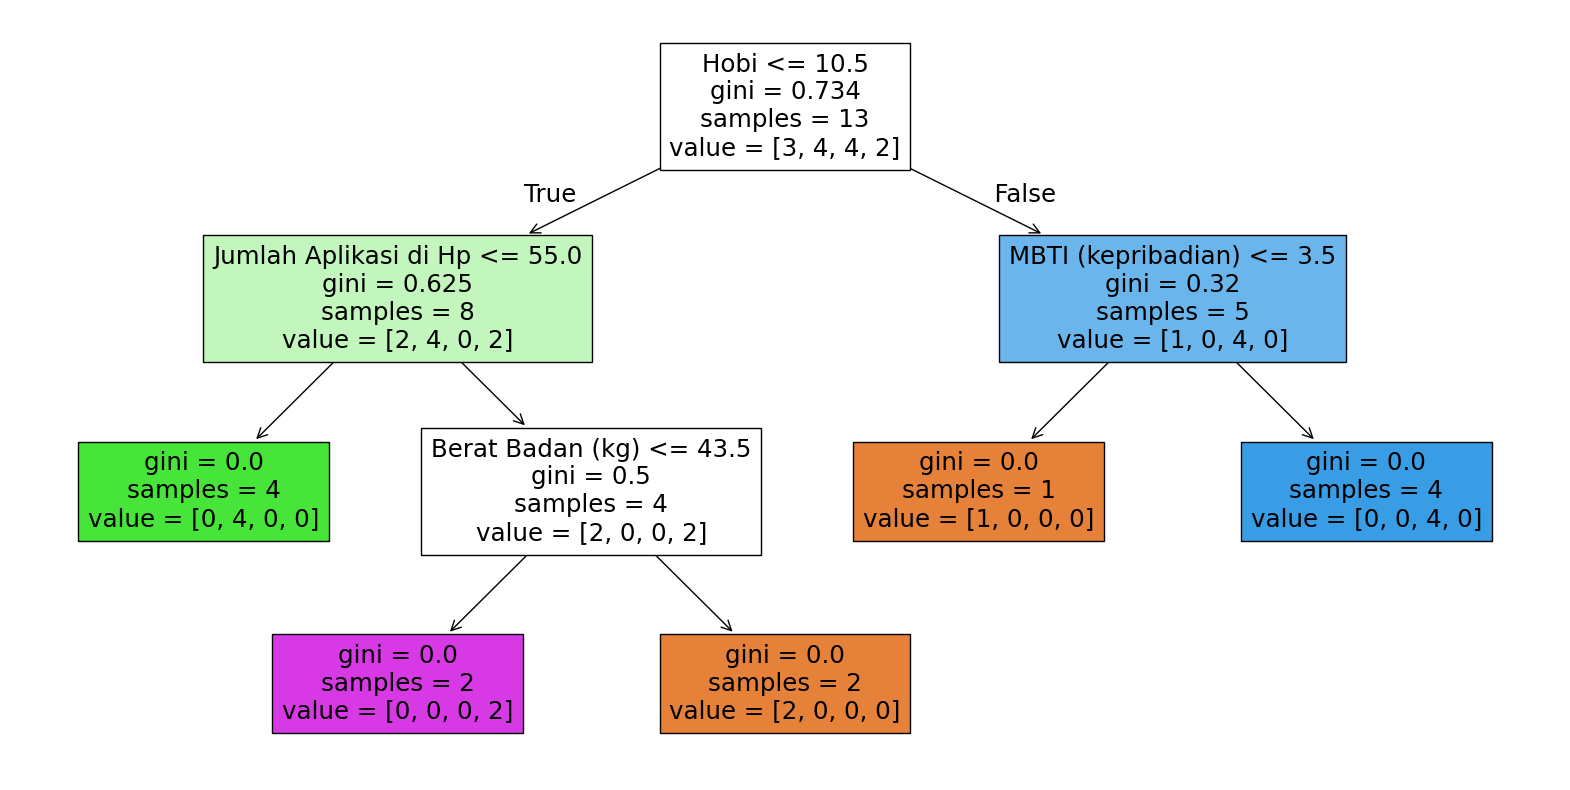

In [14]:
plt.figure(
    figsize=(20,10)
)


plot_tree(
    model_dt,
    feature_names=X.columns,
    filled=True
)


plt.show()